In [30]:
import numpy as np
import matplotlib.pyplot as plt
import copy

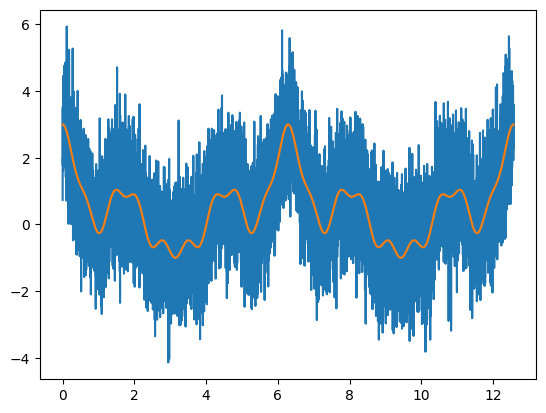

In [31]:
N = 10001
time = np.linspace(0,4*np.pi,N)

signal = np.zeros(N)

for j in range(1,4):
  signal += np.cos(j*time)**j

noisysignal = signal + np.random.randn(N)

plt.plot(time,noisysignal, time,signal)
plt.show()

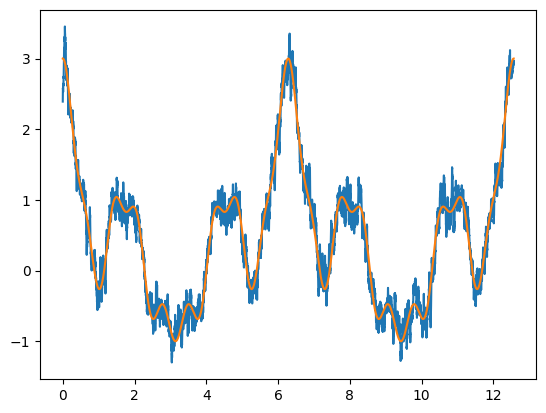

In [32]:
# Mean Smoothing Filter
filtered_signal = copy.deepcopy(noisysignal)

k = 15

for t in range(N):
  lower_bound = np.max((0,t-k))
  upper_bound = np.min((N,t+k))
  filtered_signal[t] = np.mean(noisysignal[lower_bound:upper_bound])

plt.plot(time,filtered_signal, time,signal)
plt.show()

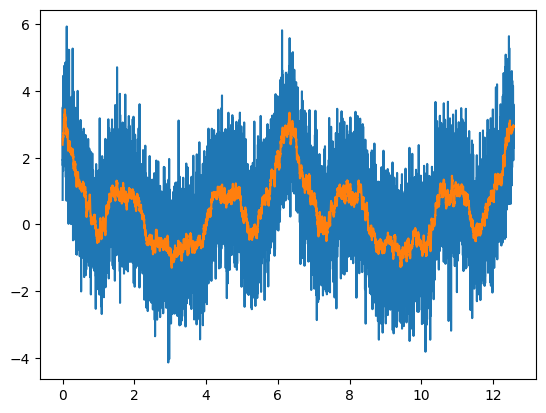

In [33]:
plt.plot(time, noisysignal, time, filtered_signal)

In [37]:
def mean_smooth(signalIn, k):
  filtered_signal = copy.deepcopy(signalIn)

  for t in range(N):
    filtered_signal[t] = np.mean(noisysignal[np.max((0,t-k)):np.min((N,t+k))])
  return filtered_signal

k_values = np.arange(5, 41)
signal_corrs = []


for k_index in k_values:
  # filter the signal
  f_signal = mean_smooth(noisysignal, k_index)

  # compute the correlation signal and original
  signal_corrs.append(np.corrcoef(f_signal, signal)[0, 1])

In [38]:
signal_corrs

[np.float64(0.9520225364146871),
 np.float64(0.9599241868748817),
 np.float64(0.9655672575241281),
 np.float64(0.969880038330964),
 np.float64(0.973315105318972),
 np.float64(0.9760045591319874),
 np.float64(0.9782083094234605),
 np.float64(0.9800376427013566),
 np.float64(0.9816374570203363),
 np.float64(0.9829862330760603),
 np.float64(0.9841960577508275),
 np.float64(0.9852295738231281),
 np.float64(0.9861786552790376),
 np.float64(0.9870240787067267),
 np.float64(0.9878017747055245),
 np.float64(0.9884964894436329),
 np.float64(0.9891224739743855),
 np.float64(0.9897026707734271),
 np.float64(0.9902003947757171),
 np.float64(0.9906481818404537),
 np.float64(0.9910565087965513),
 np.float64(0.9914159312817878),
 np.float64(0.9917405513674172),
 np.float64(0.9920374418424335),
 np.float64(0.9923082586948059),
 np.float64(0.9925686938734115),
 np.float64(0.9928279239602752),
 np.float64(0.9930774051127633),
 np.float64(0.993311502284483),
 np.float64(0.9935347434720009),
 np.float64(0

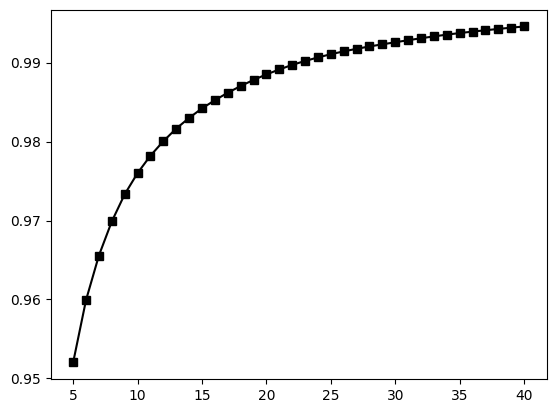

In [39]:
plt.plot(k_values, signal_corrs, 'ks-')